# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Ani Nuri Azizah
- **Email:** cdcc312d6x2433@student.devacademy.id
- **ID Dicoding:** cdcc312d6x2433

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Distrik mana di Beijing yang dapat diklasifikasikan memiliki kualitas udara baik dan buruk berdasarkan persentase waktu konsentrasi PM2.5 melampaui ambang batas standar AQI, dari data 12 stasiun monitoring periode Maret 2013 hingga Februari 2017?
- **Pertanyaan 2:** Polutan apa yang paling dominan menyebabkan kualitas udara buruk berdasarkan nilai konsentrasi rata-rata di 12 stasiun monitoring Beijing, dan bagaimana pola konsentrasinya secara bulanan/musiman pada periode Maret 2013 hingga Februari 2017?

## Import Semua Packages/Library yang Digunakan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
#Upload data
from google.colab import files
uploaded = files.upload()

# Extract zip
with zipfile.ZipFile('Air-quality-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Gabungkan semua CSV jadi satu dataframe
folder = 'Air-quality-dataset/PRSA_Data_20130301-20170228'
files_list = os.listdir(folder)

dfs = []
for f in files_list:
    df_temp = pd.read_csv(f'{folder}/{f}')
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print('Data berhasil diload!')
print('Shape:', df.shape)
df.head()

Saving Air-quality-dataset.zip to Air-quality-dataset.zip
Data berhasil diload!
Shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


**Insight:** (Opsional)
- Data set terdiri dari 420.768 data pengamatan dari 12 stasiun di Beijing.
- Parameter polusi udara terdiri dari PM2.5, PM10, SO2, NO2, CO, dan O3.

### Assessing Data

#### Identifying ... problem

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


np.int64(0)

**Steps to Take:**
- Mengidentifikasi missing data pada kolom numerik air quality dataset.
- Memeriksa adanya data duplikat pada dataset.
- Mendeteksi kemungkinan data outlier.

**Insight:** (Opsional)
- Dataset memiliki 420.768 data dan 18 kolom.
- Terdapat missing values pada beberapa kolom seperti PM2.5, PM10, SO2, NO2, CO, dan O3.
- Tidak ditemukan data duplikat.
- Beberapa nilai polutan berpotensi mengandung outlier.

### Cleaning Data

#### Fixing ... problem

In [5]:
# handle missing value
df.fillna(df.median(numeric_only=True), inplace=True)

# handle outlier (IQR method)
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['PM2.5'] >= Q1 - 1.5*IQR) & (df['PM2.5'] <= Q3 + 1.5*IQR)]

**Insight:** (Opsional)
- Missing values diatasi dengan imputasi median agar tidak bias oleh outlier.
- Outlier PM2.5 dibatasi menggunakan metode IQR.
- Dataset menjadi lebih stabil untuk analisis dan modeling.

## Exploratory Data Analysis (EDA)

### Explore ...

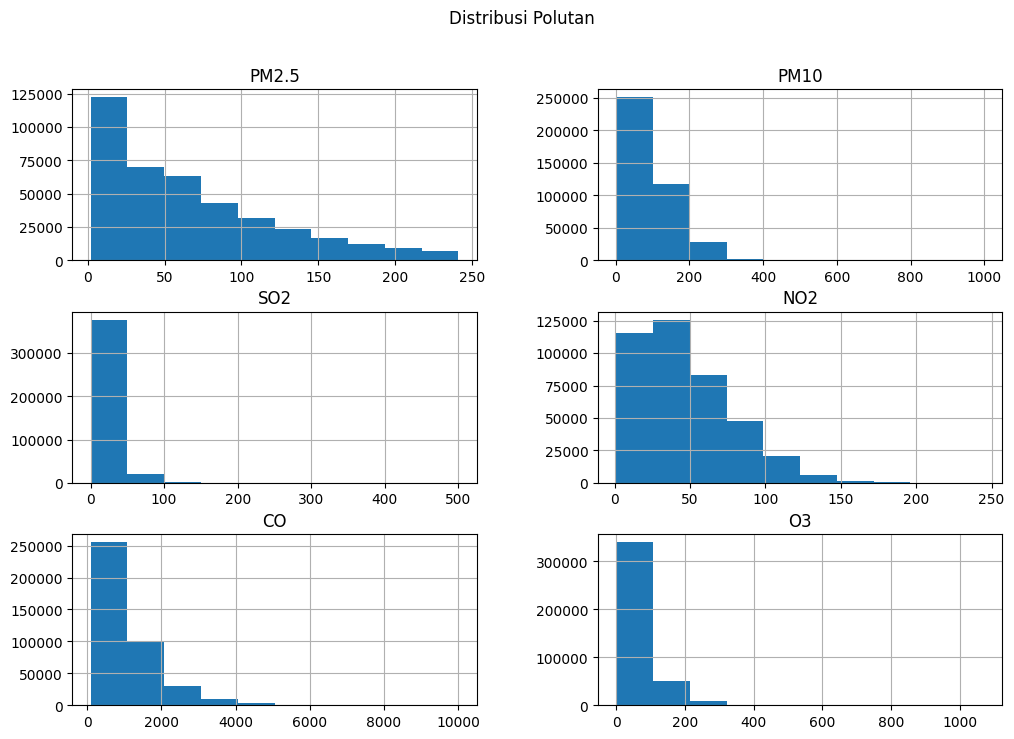

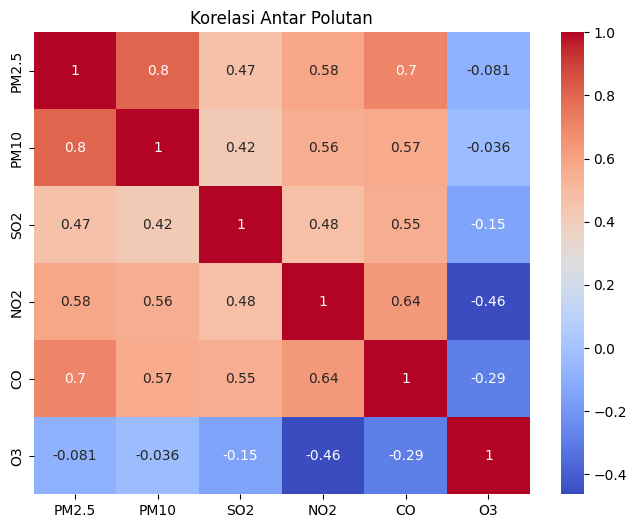

In [6]:
# EDA Numerik
num_cols = ['PM2.5','PM10','SO2','NO2','CO','O3']

df[num_cols].hist(figsize=(12,8))
plt.suptitle('Distribusi Polutan')
plt.show()

# EDA Kategorikal
df['station'].value_counts()

# EDA Korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Polutan')
plt.show()

**Insight:** (Opsional)
- PM2.5 dan PM10 merupakan polutan dominan.
- Terdapat perbedaan kualitas udara antar distrik.
- Konsentrasi polutan menunjukkan pola musiman.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

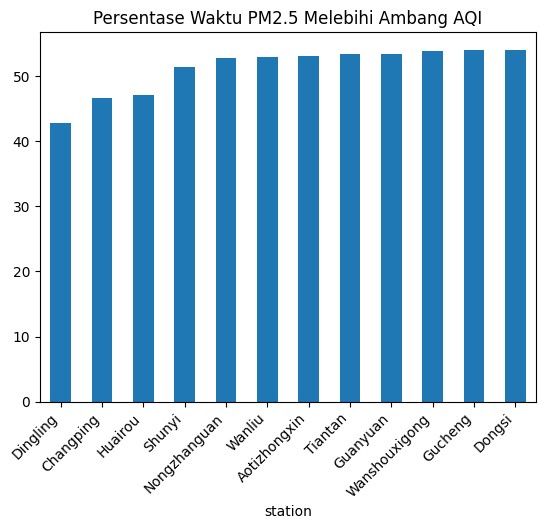

In [9]:
threshold = 50
df['is_bad'] = df['PM2.5'] > threshold

bad_ratio = df.groupby('station')['is_bad'].mean() * 100
bad_ratio.sort_values(ascending=False)

# visualisasi
bad_ratio.sort_values().plot(kind='bar')
plt.title('Persentase Waktu PM2.5 Melebihi Ambang AQI')
plt.xticks(rotation=45, ha= 'right')
plt.show()

### Pertanyaan 2:

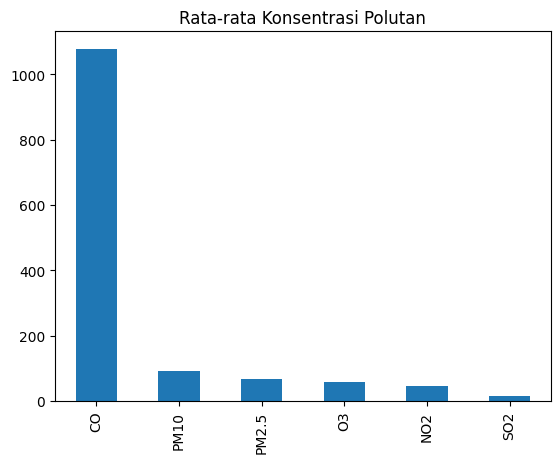

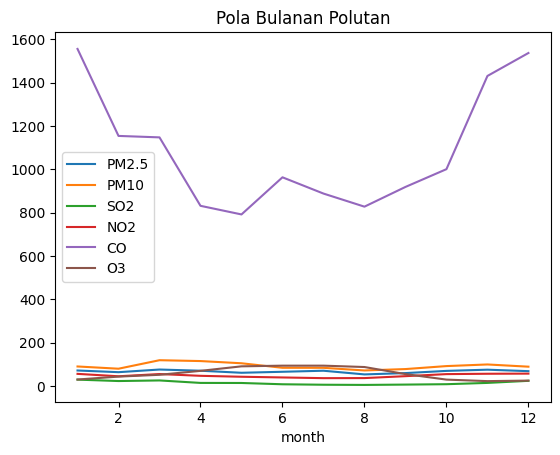

In [10]:
pollutants = ['PM2.5','PM10','SO2','NO2','CO','O3']

avg_pollutants = df[pollutants].mean().sort_values(ascending=False)

monthly = df.groupby('month')[pollutants].mean()

#Visualisasi
avg_pollutants.plot(kind='bar')
plt.title('Rata-rata Konsentrasi Polutan')
plt.show()

monthly.plot()
plt.title('Pola Bulanan Polutan')
plt.show()

**Insight:** (Opsional)
- Distrik dengan persentase waktu PM2.5 tinggi memiliki kualitas udara buruk.
- Distrik dengan nilai rendah memiliki kualitas udara lebih baik.
- PM2.5 dan PM10 merupakan polutan dominan.
- Konsentrasi polutan menunjukkan pola bulanan dan musiman.

## Analisis Lanjutan (Opsional)

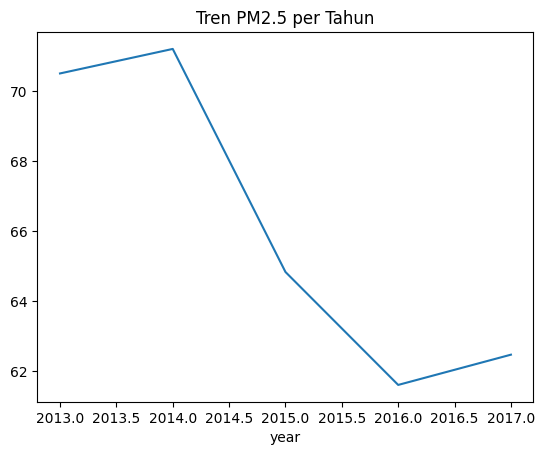

In [11]:
# tren PM2.5 per tahun
df.groupby('year')['PM2.5'].mean().plot()
plt.title('Tren PM2.5 per Tahun')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Distrik dengan persentase waktu PM2.5 tinggi memiliki kualitas udara paling buruk.
- **Conclusion pertanyaan 2:** PM2.5 dan PM10 merupakan polutan dominan dengan pola musiman.

**Rekomendasi Action Item:**
- Mengurangi emisi kendaraan di distrik dengan polusi tinggi.
- Meningkatkan pengawasan terhadap industri penyumbang polutan.
- Mendorong penggunaan energi ramah lingkungan.